In [1]:
pip install emoji vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 94.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 48.0 MB/s eta 0:00:00
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=eeb01b03281b6ea59177092fa400b384273eafd153f1e5bdb909fbfd5398fd8b
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp


In [2]:
import html
import inspect
import random
import re
import unicodedata
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence
from urllib.request import urlretrieve

import emoji
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from vncorenlp import VnCoreNLP


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Config

In [4]:
run_name = "uit-vsfc-uni-e5-small"
train_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/university/train.csv")
val_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/university/validation.csv")
test_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/university/test.csv")
pretrained_model_name = "intfloat/multilingual-e5-small"


In [5]:
epochs = 20
batch_size = 21
max_length = 256
learning_rate = 2e-4
weight_decay = 0.0
warmup_ratio = 0.1
early_stopping_patience = 7
early_stopping_min_delta = 0.0
num_workers = 0
multi_branch = False
use_text_preprocessing = True
seed = 42

output_dir = Path("/content/drive/MyDrive/bachnt/KHDL/checkpoints")
prediction_dir = Path("/content/drive/MyDrive/bachnt/KHDL/predictions")


# Preprocess

## Label Mapping


In [6]:
class SentimentMapping:
    INDEX_TO_LABEL = {0: "negative", 1: "neutral", 2: "positive"}
    NUM_CLASSES = 3


class TopicMapping:
    INDEX_TO_LABEL = {0: "lecturer", 1: "training_program", 2: "facility", 3: "others"}
    NUM_CLASSES = 4


TASK_NAMES: tuple[str, ...] = ("sentiment", "topic")
NUM_CLASSES_BY_TASK = {"sentiment": SentimentMapping.NUM_CLASSES, "topic": TopicMapping.NUM_CLASSES}


##  Word Segmentation


In [7]:
VNCORENLP_BASE_URL = "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master"
VNCORENLP_FILES = [
    "VnCoreNLP-1.2.jar",
    "models/wordsegmenter/vi-vocab",
    "models/wordsegmenter/wordsegmenter.rdr",
]
WORD_SEGMENTER: VnCoreNLP | None = None


def ensure_vncorenlp(vncorenlp_dir: str | Path = "VnCoreNLP") -> Path:
    vncorenlp_dir = Path(vncorenlp_dir)
    for relative_path in VNCORENLP_FILES:
        local_path = vncorenlp_dir / relative_path
        if local_path.exists():
            continue
        local_path.parent.mkdir(parents=True, exist_ok=True)
        url = f"{VNCORENLP_BASE_URL}/{relative_path}"
        print(f"Downloading {url} -> {local_path}")
        urlretrieve(url, local_path)
    return vncorenlp_dir


def get_word_segmenter() -> VnCoreNLP:
    global WORD_SEGMENTER
    if WORD_SEGMENTER is None:
        vncorenlp_dir = ensure_vncorenlp()
        WORD_SEGMENTER = VnCoreNLP(
            str(vncorenlp_dir / "VnCoreNLP-1.2.jar"),
            annotators="wseg",
            quiet=True,
        )
    return WORD_SEGMENTER


## Text Cleaning


In [8]:
TEENCODE_URL = "https://raw.githubusercontent.com/NeoCyber05/Aspect_Based_Sentiment_Analysis_for_Place_Reviews/main/training/teencode/uni_teencode.txt"
ACRONYM_MAP: dict[str, str] | None = None


def build_acronym_map(teencode_path: str | Path = "teencode.txt") -> dict[str, str]:
    teencode_path = Path(teencode_path)
    print(f"Downloading {TEENCODE_URL} -> {teencode_path}")
    urlretrieve(TEENCODE_URL, teencode_path)
    mapping: dict[str, str] = {}
    for line in teencode_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        if "\t" in line:
            teencode, normalized = line.split("\t", 1)
        elif " - " in line:
            teencode, normalized = line.split(" - ", 1)
        else:
            continue
        teencode = teencode.strip().lower()
        normalized = normalized.strip()
        if teencode and normalized:
            mapping[teencode] = normalized
    return mapping


def normalize_acronyms(text: str) -> str:
    global ACRONYM_MAP
    if ACRONYM_MAP is None:
        ACRONYM_MAP = build_acronym_map()
    return " ".join(ACRONYM_MAP.get(word.lower(), word) for word in text.split())


def remove_HTML(text: str) -> str:
    text = html.unescape(str(text))
    return re.sub(r"<[^>]+>", " ", text)


def convert_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", text)


def word_segmentation(text: str) -> str:
    sentences = get_word_segmenter().tokenize(text)
    return " ".join(token for sentence in sentences for token in sentence)


def remove_unnecessary_characters(text: str) -> str:
    text = emoji.replace_emoji(text, " ")
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def text_preprocess(text: str) -> str:
    text = remove_HTML(text)
    text = convert_unicode(text)
    text = normalize_acronyms(text)
    text = word_segmentation(text)
    return remove_unnecessary_characters(text)


# Dataset


In [9]:
TEXT_COLUMN = "sentence"


class UniVsfcCsvDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        aspect_category_names: Sequence[str],
        text_preprocessor=None,
    ) -> None:
        self.csv_path = Path(csv_path)
        self.frame = pd.read_csv(self.csv_path)
        self.aspect_category_names = list(aspect_category_names)
        self.raw_texts = self.frame[TEXT_COLUMN].astype(str).tolist()
        if text_preprocessor is None:
            self.texts = self.raw_texts
        else:
            self.texts = [
                text_preprocessor(text)
                for text in tqdm(self.raw_texts, desc=f"preprocess {self.csv_path.name}", leave=False)
            ]
        self.labels = self.frame[self.aspect_category_names].astype("int64").to_numpy()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict[str, object]:
        return {"text": self.texts[index], "labels": self.labels[index]}


## Collator And Dataloaders


In [10]:
@dataclass
class UniVsfcCollator:
    tokenizer: object
    max_length: int = 256

    def __call__(self, examples: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        texts = [str(example["text"]) for example in examples]
        labels = torch.tensor(np.stack([example["labels"] for example in examples]), dtype=torch.long)
        encoded = self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        encoded["labels"] = labels
        return encoded


def build_dataloaders(
    train_csv_path: str | Path,
    val_csv_path: str | Path,
    test_csv_path: str | Path,
    tokenizer: object,
    aspect_category_names: Sequence[str],
    batch_size: int = 8,
    max_length: int = 256,
    num_workers: int = 0,
    text_preprocessor=None,
) -> tuple[dict[str, DataLoader], list[str]]:
    paths = {
        "train": Path(train_csv_path),
        "val": Path(val_csv_path),
        "test": Path(test_csv_path),
    }
    cols = list(aspect_category_names)
    collator = UniVsfcCollator(tokenizer=tokenizer, max_length=max_length)
    datasets = {
        split: UniVsfcCsvDataset(path, aspect_category_names=cols, text_preprocessor=text_preprocessor)
        for split, path in paths.items()
    }
    loaders = {
        "train": DataLoader(datasets["train"], batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collator),
        "val": DataLoader(datasets["val"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
        "test": DataLoader(datasets["test"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
    }
    return loaders, cols


# Model

In [11]:
class TransformerUniVsfc(nn.Module):
    def __init__(
        self,
        pretrained_model_name: str,
        aspect_category_names: Iterable[str],
        num_classes_by_task: dict[str, int],
        multi_branch: bool = False,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.aspect_category_names = list(aspect_category_names)
        self.multi_branch = multi_branch
        self.num_classes_by_task = {k: num_classes_by_task[k] for k in self.aspect_category_names}
        self.transformer = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.transformer.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict(
            {name: nn.Linear(hidden_size, self.num_classes_by_task[name]) for name in self.aspect_category_names}
        )
        self._transformer_forward_args = set(inspect.signature(self.transformer.forward).parameters)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> dict[str, torch.Tensor]:
        model_inputs = {"input_ids": input_ids}
        if attention_mask is not None:
            model_inputs["attention_mask"] = attention_mask
        if token_type_ids is not None and "token_type_ids" in self._transformer_forward_args:
            model_inputs["token_type_ids"] = token_type_ids

        outputs = self.transformer(**model_inputs)
        token_embeddings = outputs.last_hidden_state
        if attention_mask is None:
            pooled_output = token_embeddings.mean(dim=1)
        else:
            mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
            pooled_output = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        pooled_output = self.dropout(pooled_output)
        return {name: self.heads[name](pooled_output) for name in self.aspect_category_names}


# Eval

In [12]:
class UniVsfcSklearnEvaluator:
    def __init__(self, y_test, y_pred, aspect_category_names: Sequence[str]):
        y_test = np.asarray(y_test)
        y_pred = np.asarray(y_pred)
        self.aspect_category_names = list(aspect_category_names)
        self.sentiment_report = classification_report(
            y_test[:, 0],
            y_pred[:, 0],
            target_names=[SentimentMapping.INDEX_TO_LABEL[i] for i in range(SentimentMapping.NUM_CLASSES)],
            digits=4,
            zero_division=0,
            output_dict=True,
        )
        self.topic_report = classification_report(
            y_test[:, 1],
            y_pred[:, 1],
            target_names=[TopicMapping.INDEX_TO_LABEL[i] for i in range(TopicMapping.NUM_CLASSES)],
            digits=4,
            zero_division=0,
            output_dict=True,
        )

    def report(self, report_type: str):
        if report_type == "sentiment":
            return pd.DataFrame(self.sentiment_report).T
        if report_type == "topic":
            return pd.DataFrame(self.topic_report).T
        raise ValueError('report_type must be "sentiment" or "topic"')


# Training

In [13]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in batch.items()}


def model_inputs(batch: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    allowed = {"input_ids", "attention_mask", "token_type_ids"}
    return {key: value for key, value in batch.items() if key in allowed}


def logits_from_forward(model: TransformerUniVsfc, batch: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    return model(**model_inputs(batch))


def logits_to_predictions_matrix(logits_by_task: dict[str, torch.Tensor], aspect_category_names: Sequence[str]) -> torch.Tensor:
    return torch.stack(
        [logits_by_task[name].argmax(dim=-1) for name in aspect_category_names],
        dim=1,
    )


def compute_loss(model: TransformerUniVsfc, criterion: nn.Module, batch: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
    labels = batch["labels"]
    logits_by_task = logits_from_forward(model, batch)
    losses = []
    for task_index, name in enumerate(model.aspect_category_names):
        losses.append(criterion(logits_by_task[name], labels[:, task_index]))
    loss = torch.stack(losses).mean()
    return loss, logits_by_task


def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device: torch.device) -> float:
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        loss, _ = compute_loss(model, criterion, batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(1, len(dataloader))


@torch.no_grad()
def evaluate(model, dataloader, criterion, device: torch.device) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(dataloader, desc="eval", leave=False):
        batch = move_batch_to_device(batch, device)
        loss, logits_by_task = compute_loss(model, criterion, batch)
        predictions = logits_to_predictions_matrix(logits_by_task, model.aspect_category_names)
        labels = batch["labels"]
        total_loss += loss.item()
        correct += (predictions == labels).sum().item()
        total += labels.numel()
    return {"loss": total_loss / max(1, len(dataloader)), "accuracy": correct / max(1, total)}


def save_checkpoint(path: Path, model: TransformerUniVsfc, optimizer: torch.optim.Optimizer, epoch: int, metrics: dict[str, float]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "metrics": metrics,
            "pretrained_model_name": pretrained_model_name,
            "aspect_category_names": model.aspect_category_names,
            "multi_branch": model.multi_branch,
            "num_classes_by_task": model.num_classes_by_task,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        path,
    )


def plot_training_history(history: dict[str, list[float]], figsize=(15, 5)) -> None:
    plt.figure(figsize=figsize)
    plt.plot(history["loss"], linestyle="solid", marker="o", color="crimson", label="Train")
    if "val_loss" in history:
        plt.plot(history["val_loss"], linestyle="solid", marker="o", color="dodgerblue", label="Validation")
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Loss", fontsize=15)
    plt.legend(loc="best")
    plt.show()


def save_predictions(save_path: str | Path, raw_texts, predictions: np.ndarray, aspect_category_names: Sequence[str]) -> None:
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    name_to_col = {n: idx for idx, n in enumerate(aspect_category_names)}
    sentiment_idx = name_to_col["sentiment"]
    topic_idx = name_to_col["topic"]
    with save_path.open("w", encoding="utf-8") as file:
        for index in tqdm(range(len(raw_texts)), desc="write predictions", leave=False):
            s_lab = SentimentMapping.INDEX_TO_LABEL[int(predictions[index, sentiment_idx])]
            t_lab = TopicMapping.INDEX_TO_LABEL[int(predictions[index, topic_idx])]
            annotation_text = (
                f"{{{aspect_category_names[0]}, {s_lab}}}, {{{aspect_category_names[1]}, {t_lab}}}"
            )
            file.write(f"#{index + 1}\n{raw_texts[index]}\n{annotation_text}\n\n")


In [14]:
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)

def preprocess_for_model(text: str) -> str:
    return text_preprocess(text)


active_text_preprocessor = preprocess_for_model if use_text_preprocessing else None
print(f"Text preprocessing: {'enabled' if active_text_preprocessor else 'disabled'}")

loaders, aspect_category_names = build_dataloaders(
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    tokenizer=tokenizer,
    aspect_category_names=list(TASK_NAMES),
    batch_size=batch_size,
    max_length=max_length,
    num_workers=num_workers,
    text_preprocessor=active_text_preprocessor,
)

print(device)
print(f"train: {train_csv_path}")
print(f"val: {val_csv_path}")
print(f"test: {test_csv_path}")
print(f"Aspects: {len(aspect_category_names)}")
print(aspect_category_names)
print({split: len(loader.dataset) for split, loader in loaders.items()})
print("Raw sample:", loaders["train"].dataset.raw_texts[0][:250])
print("Model input sample:", loaders["train"].dataset.texts[0][:250])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Text preprocessing: enabled


preprocess train.csv:   0%|          | 0/11426 [00:00<?, ?it/s]

preprocess validation.csv:   0%|          | 0/1583 [00:00<?, ?it/s]

preprocess test.csv:   0%|          | 0/3166 [00:00<?, ?it/s]

cuda
train: /content/drive/MyDrive/bachnt/KHDL/university/train.csv
val: /content/drive/MyDrive/bachnt/KHDL/university/validation.csv
test: /content/drive/MyDrive/bachnt/KHDL/university/test.csv
Aspects: 2
['sentiment', 'topic']
{'train': 11426, 'val': 1583, 'test': 3166}
Raw sample: slide giáo trình đầy đủ .
Model input sample: slide giáo_trình đầy_đủ


In [15]:
model = TransformerUniVsfc(
    pretrained_model_name=pretrained_model_name,
    aspect_category_names=aspect_category_names,
    num_classes_by_task=NUM_CLASSES_BY_TASK,
    multi_branch=False,
).to(device)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

total_steps = len(loaders["train"]) * epochs
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total train steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total train steps: 10900
Warmup steps: 1090


In [16]:
history = {"loss": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")
epochs_without_improvement = 0

best_checkpoint_path = output_dir / f"{run_name}-best.pt"
last_checkpoint_path = output_dir / f"{run_name}-last.pt"

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, loaders["train"], optimizer, scheduler, criterion, device)
    val_metrics = evaluate(model, loaders["val"], criterion, device)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    print(
        f"epoch={epoch} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.4f}"
    )

    save_checkpoint(last_checkpoint_path, model, optimizer, epoch, val_metrics)
    if val_metrics["loss"] < best_val_loss - early_stopping_min_delta:
        best_val_loss = val_metrics["loss"]
        epochs_without_improvement = 0
        save_checkpoint(best_checkpoint_path, model, optimizer, epoch, val_metrics)
        print(f"Saved best checkpoint: {best_checkpoint_path}")
    else:
        epochs_without_improvement += 1
        print(
            f"No val_loss improvement for "
            f"{epochs_without_improvement}/{early_stopping_patience} epochs"
        )
        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.4f}")
            break

pd.DataFrame(history)


train:   0%|          | 0/545 [00:00<?, ?it/s]

eval:   0%|          | 0/76 [00:00<?, ?it/s]

epoch=1 train_loss=0.5772 val_loss=0.3808 val_accuracy=0.8752
Saved best checkpoint: /content/drive/MyDrive/bachnt/KHDL/checkpoints/uit-vsfc-uni-e5-small-best.pt


train:   0%|          | 0/545 [00:00<?, ?it/s]

eval:   0%|          | 0/76 [00:00<?, ?it/s]

...

epoch=10 train_loss=0.1485 val_loss=0.3147 val_accuracy=0.9030
No val_loss improvement for 6/7 epochs


train:   0%|          | 0/545 [00:00<?, ?it/s]

eval:   0%|          | 0/76 [00:00<?, ?it/s]

epoch=11 train_loss=0.1311 val_loss=0.3378 val_accuracy=0.9021
No val_loss improvement for 7/7 epochs
Early stopping at epoch 11. Best val_loss=0.2894


,loss,val_loss,val_accuracy
0,0.577189,0.380792,0.875237
1,0.358117,0.327422,0.891661
2,0.320279,0.344012,0.882186
3,0.291833,0.289353,0.900505
4,0.257514,0.315130,0.893872
5,0.240055,0.312398,0.903348
6,0.218247,0.300709,0.906191
7,0.191072,0.319498,0.892293
8,0.179850,0.320320,0.901769
9,0.148488,0.314677,0.903032


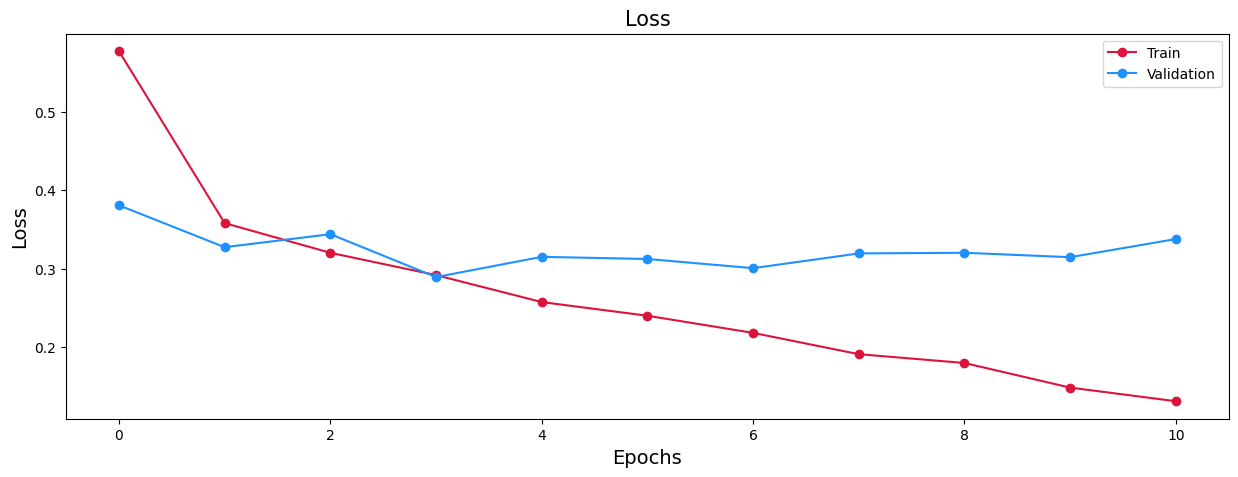

In [19]:
plot_training_history(history)


In [20]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_metrics = evaluate(model, loaders["test"], criterion, device)
test_metrics


eval:   0%|          | 0/151 [00:00<?, ?it/s]

{'loss': 0.32847776710493676, 'accuracy': 0.8891345546430828}

In [21]:
@torch.no_grad()
def predict_dataloader(model: TransformerUniVsfc, dataloader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_labels = []
    all_predictions = []
    for batch in tqdm(dataloader, desc="predict", leave=False):
        batch = move_batch_to_device(batch, device)
        logits_by_task = model(**model_inputs(batch))
        predictions = logits_to_predictions_matrix(logits_by_task, model.aspect_category_names)
        all_labels.append(batch["labels"].detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
    return np.concatenate(all_labels, axis=0), np.concatenate(all_predictions, axis=0)


y_test, y_pred = predict_dataloader(model, loaders["test"], device)
evaluator = UniVsfcSklearnEvaluator(y_test, y_pred, aspect_category_names)
evaluator.report("sentiment")


predict:   0%|          | 0/151 [00:00<?, ?it/s]

,precision,recall,f1-score,support
negative,0.899120,0.942512,0.920305,1409.000000
neutral,0.661290,0.245509,0.358079,167.000000
positive,0.912108,0.933333,0.922599,1590.000000
accuracy,0.901137,0.901137,0.901137,0.901137
macro avg,0.824173,0.707118,0.733661,3166.000000
weighted avg,0.893098,0.901137,0.891801,3166.000000


In [22]:
evaluator.report("topic")


,precision,recall,f1-score,support
lecturer,0.920906,0.940611,0.930655,2290.000000
training_program,0.730579,0.772727,0.751062,572.000000
facility,0.900000,0.868966,0.884211,145.000000
others,0.670732,0.345912,0.456432,159.000000
accuracy,0.877132,0.877132,0.877132,0.877132
macro avg,0.805554,0.732054,0.755590,3166.000000
weighted avg,0.872998,0.877132,0.872265,3166.000000


In [23]:
save_path = prediction_dir / f"{run_name}_test_predictions.txt"
save_predictions(save_path, loaders["test"].dataset.raw_texts, y_pred, aspect_category_names)


write predictions:   0%|          | 0/3166 [00:00<?, ?it/s]

In [25]:
@torch.no_grad()
def predict_texts(texts: str | list[str]) -> np.ndarray:
    if isinstance(texts, str):
        texts = [texts]

    model_texts = [active_text_preprocessor(text) for text in texts] if active_text_preprocessor else texts
    encoded = tokenizer(
        model_texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    model.eval()
    logits_by_task = model(**encoded)
    predictions = logits_to_predictions_matrix(logits_by_task, aspect_category_names)
    return predictions.detach().cpu().numpy()


def print_prediction(prediction_row: np.ndarray | list[int]) -> None:
    name_to_col = {name: idx for idx, name in enumerate(aspect_category_names)}
    sentiment_idx = name_to_col["sentiment"]
    topic_idx = name_to_col["topic"]

    sentiment_label = SentimentMapping.INDEX_TO_LABEL[int(prediction_row[sentiment_idx])]
    topic_label = TopicMapping.INDEX_TO_LABEL[int(prediction_row[topic_idx])]

    print(f"sentiment: {sentiment_label}")
    print(f"topic: {topic_label}")

In [29]:
sample_text = "em học bên chất lượng cao mà phòng máy không cung cấp đủ máy ( vì máy hư hoặc không cài chương trình ) ."
sample_predictions = predict_texts(sample_text)
print(sample_predictions)
print_prediction(sample_predictions[0])

[[0 2]]
sentiment: negative
topic: facility
